In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report , confusion_matrix 

df = pd.read_csv('../data/sudair_solar_ready_for_model.csv')



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date_time          3182 non-null   object 
 1   plant_id           3182 non-null   int64  
 2   ambient_temp       3182 non-null   float64
 3   module_temp        3182 non-null   float64
 4   irradiation        3182 non-null   float64
 5   dust_level         3182 non-null   float64
 6   needs_maintenance  3182 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 174.1+ KB


In [6]:
df.isnull().sum()

date_time            0
plant_id             0
ambient_temp         0
module_temp          0
irradiation          0
dust_level           0
needs_maintenance    0
dtype: int64

In [8]:
df.describe()


,plant_id,ambient_temp,module_temp,irradiation,dust_level,needs_maintenance
count,3182.0,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313,0.499117,0.258328
std,0.0,3.354856,12.261222,0.300836,0.233017,0.437784
min,4135001.0,20.398505,18.140415,0.000000,0.100009,0.000000
25%,4135001.0,22.705182,21.090553,0.000000,0.297490,0.000000
50%,4135001.0,24.613814,24.618060,0.024653,0.502621,0.000000
75%,4135001.0,27.920532,41.307840,0.449588,0.699907,1.000000
max,4135001.0,35.252486,65.545714,1.221652,0.899774,1.000000


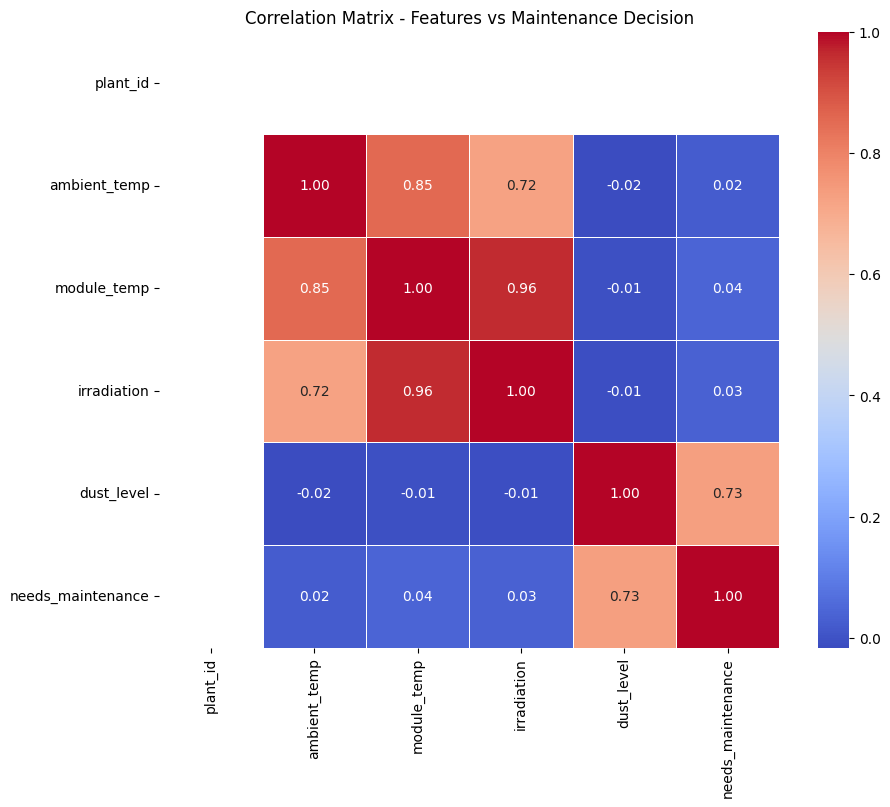

In [9]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We drop date_time for correlation as it's not a numeric factor
corr_matrix = df.drop('date_time', axis=1).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Features vs Maintenance Decision')
plt.show()

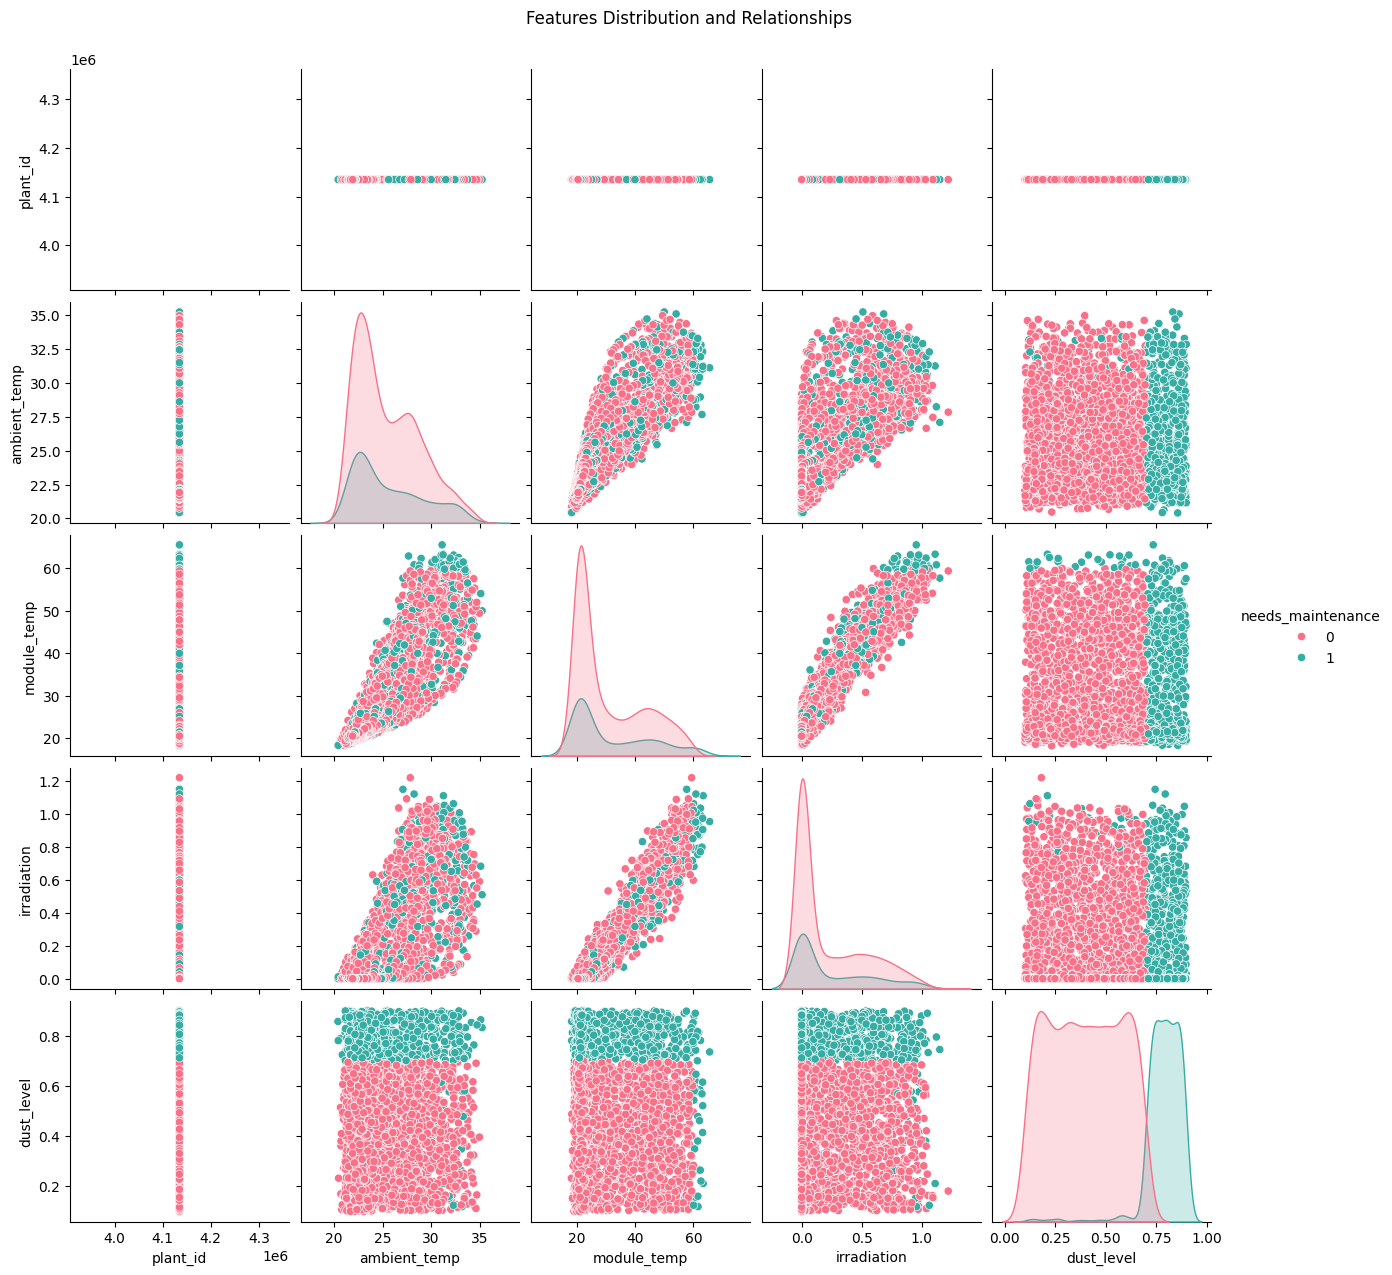

In [10]:
# 3. Pairplot to see relationships between features colored by target
sns.pairplot(df.drop('date_time', axis=1), hue='needs_maintenance', palette='husl', diag_kind='kde')
plt.suptitle('Features Distribution and Relationships', y=1.02)
plt.show()

In [11]:
X = df.drop(['date_time', 'needs_maintenance', 'plant_id'], axis=1)
y = df['needs_maintenance']

X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [14]:
scaler = StandardScaler()

In [15]:
# IMPORTANT: Fit only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Initialize Logistic Regression
model = LogisticRegression()

# Training the model
model.fit(X_train_scaled, y_train)

print("Model Training (Fitting) is finished!")

Model Training (Fitting) is finished!


In [26]:
# 1. Create the new data as a DataFrame with proper column names
new_sensor_df = pd.DataFrame([[35.0, 65.0, 0.8, 0.85]], 
                             columns=['ambient_temp', 'module_temp', 'irradiation', 'dust_level'])

# 2. Scale using the dataframe (No Warning now!)
new_data_scaled = scaler.transform(new_sensor_df)

# 3. Predict
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)

print(f"--- Real-time Inference Result ---")
if prediction[0] == 1:
    print("Decision:  MAINTENANCE REQUIRED (Cleaning Robot On)")
else:
    print("Decision:  SYSTEM HEALTHY")

print(f"Confidence Level: {probability[0][prediction[0]] * 100:.2f}%")


--- Real-time Inference Result ---
Decision:  MAINTENANCE REQUIRED (Cleaning Robot On)
Confidence Level: 99.69%


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       453
           1       0.98      0.97      0.97       184

    accuracy                           0.98       637
   macro avg       0.98      0.98      0.98       637
weighted avg       0.98      0.98      0.98       637



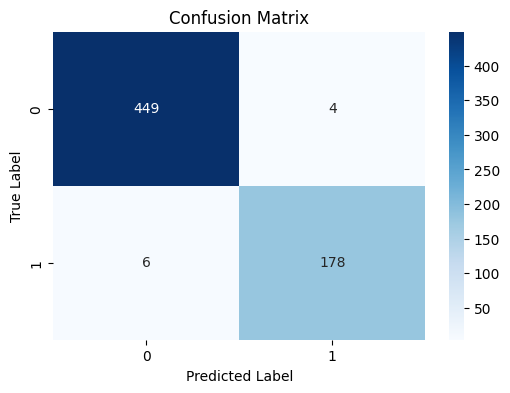

In [27]:

# 1. Predict on the test set
y_pred = model.predict(X_test_scaled)

# 2. Show the results
print("Classification Report:\n", classification_report(y_test, y_pred))

# 3. Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [28]:
import joblib 

joblib.dump(model,'solar_maintenance_model.pkl')
joblib.dump(scaler, ' data_scaler.pkl')

print("Files created: solar_maintenance_model.pkl, data_scaler.pkl")

Files created: solar_maintenance_model.pkl, data_scaler.pkl
